In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

# Plan

Phosophorylation
- Does phosphorylation affect activity?
- What is the order of importance of phosphosites?
- Are there any potential phosphosites that contribute to activity?
- Do different phosphosite sequences affect activity?


In [3]:
activity_col = "Activity_S3_1"

In [4]:
sog1_aa_features = pd.read_csv("../data/Sog1_AA_features.csv")
sog1_aa_features["PS"] = sog1_aa_features["PS_lib2"] == "confirmed"
sog1_aa_features = sog1_aa_features[["pos", "PS"]]
sog1_aa_features

,pos,PS
0,1,False
1,2,False
2,3,False
3,4,False
4,5,False
...,...,...
444,445,False
445,446,False
446,447,False
447,448,False


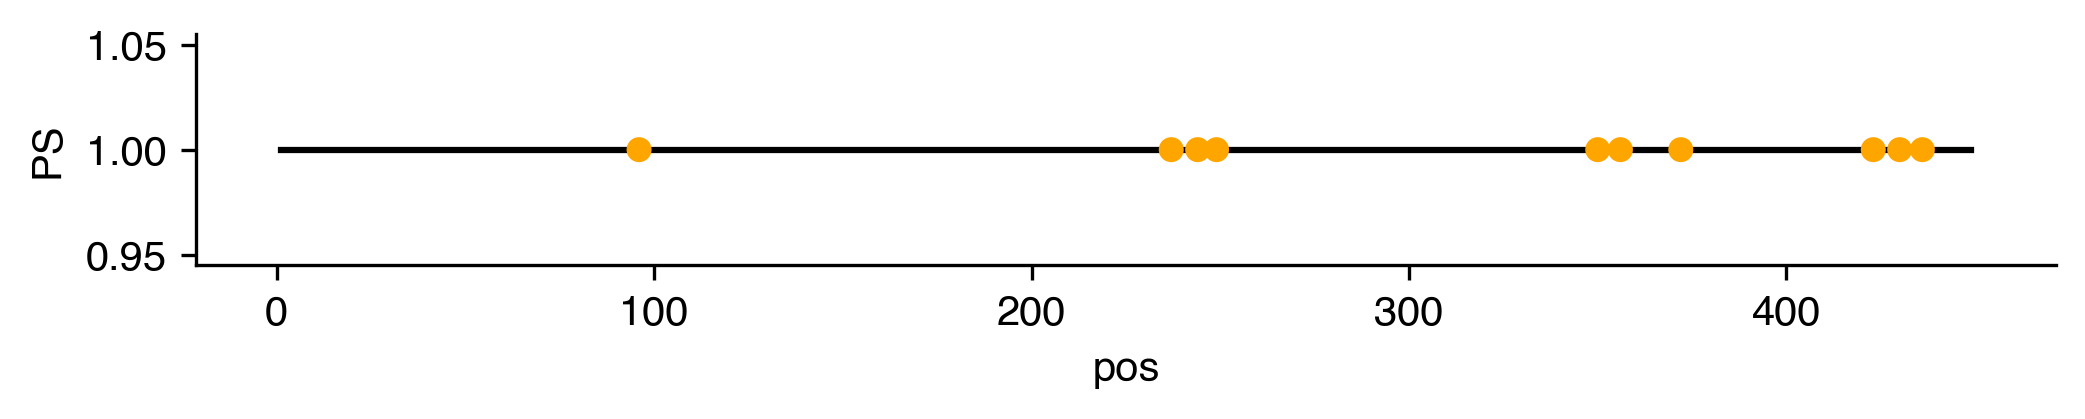

In [5]:
plt.figure(figsize = (8, 1), dpi = 300)
sns.lineplot(data = sog1_aa_features, x = "pos", y = 1, color = "black")
sns.scatterplot(data = sog1_aa_features[sog1_aa_features["PS"]], x = "pos", y = "PS", color = "orange", zorder = 10, edgecolor = "none")
sns.despine()

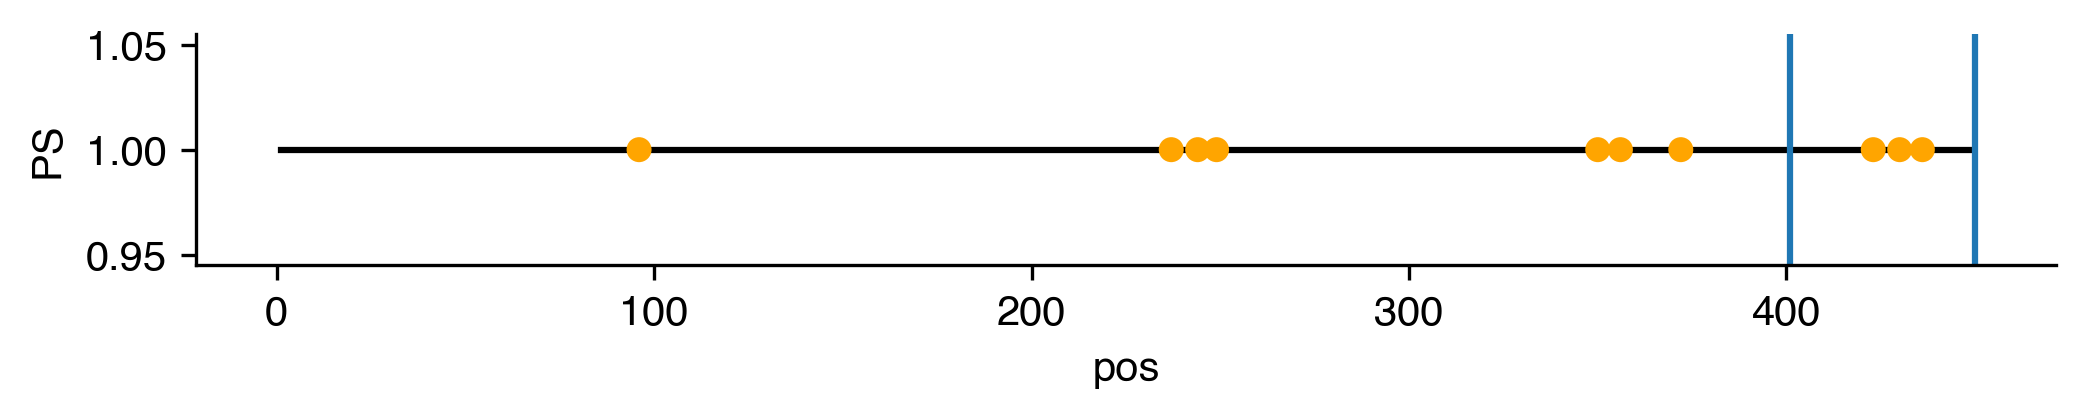

In [6]:
plt.figure(figsize = (8, 1), dpi = 300)
sns.lineplot(data = sog1_aa_features, x = "pos", y = 1, color = "black")
sns.scatterplot(data = sog1_aa_features[sog1_aa_features["PS"]], x = "pos", y = "PS", color = "orange", zorder = 10, edgecolor = "none")
plt.axvline(401)
plt.axvline(450)
sns.despine()

In [7]:
sog1_aa_features[sog1_aa_features["PS"]]

,pos,PS
95,96,True
236,237,True
243,244,True
248,249,True
349,350,True
355,356,True
371,372,True
422,423,True
429,430,True
435,436,True


In [8]:
# WT tiles
BasicArTh = sog1_helpers.return_activities("BasicArTh", pos_regex = r'\.(\d+)')

In [9]:
def plot_wt_and_ps():    
    ps_locs = sog1_aa_features[sog1_aa_features["PS"]]
    
    plt.figure(figsize = (8, 1), dpi = 300)
    ax = sns.lineplot(data = BasicArTh, x = "mid", y = activity_col, zorder = 10)
    
    for pos in ps_locs["pos"]:
        ax.axvline(pos, color = "orange", zorder = 5, alpha = 0.5, lw = 2)
    
    plt.xlabel("Tile Center")
    plt.ylabel("WT\nActivity", rotation = 0, labelpad = 21, va = 'center')
    
    sns.despine()

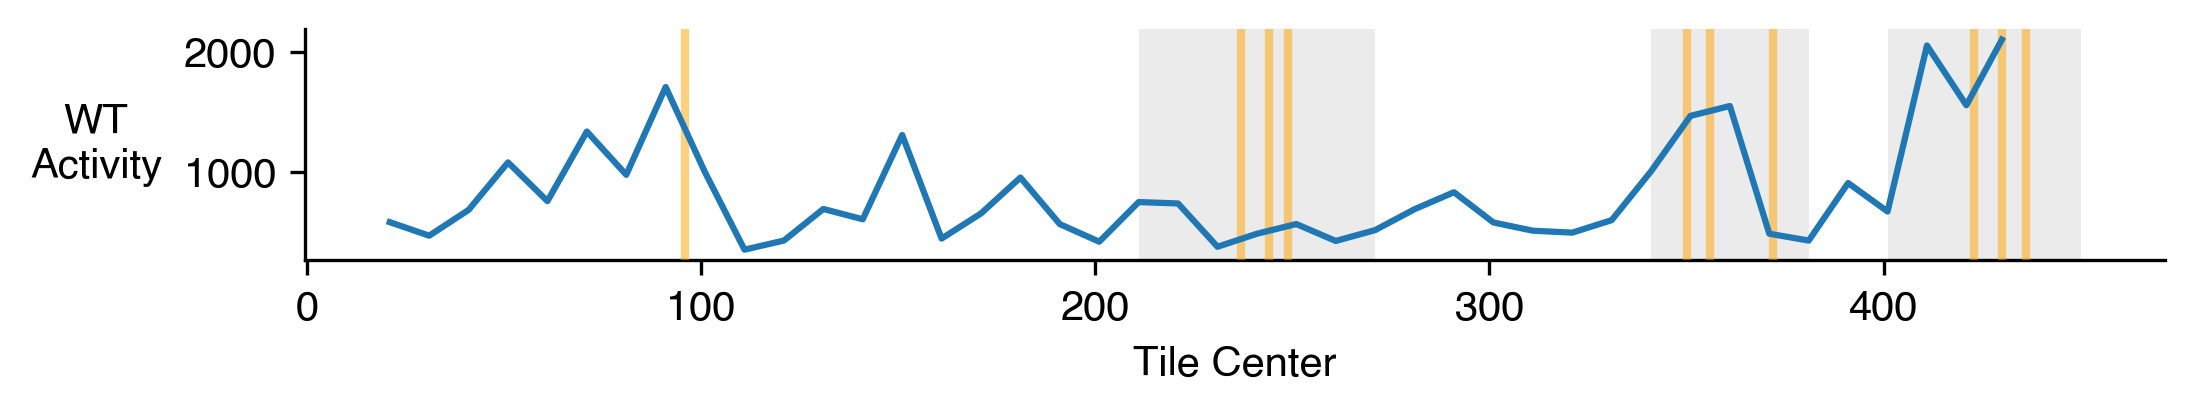

In [10]:
plot_wt_and_ps()
plt.axvspan(211, 271, facecolor='silver', alpha=0.3, label='Region A', zorder = 0)
plt.axvspan(341, 381, facecolor='silver', alpha=0.3, label='Region A', zorder = 0)
plt.axvspan(401, 450, facecolor='silver', alpha=0.3, label='Region A', zorder = 0)

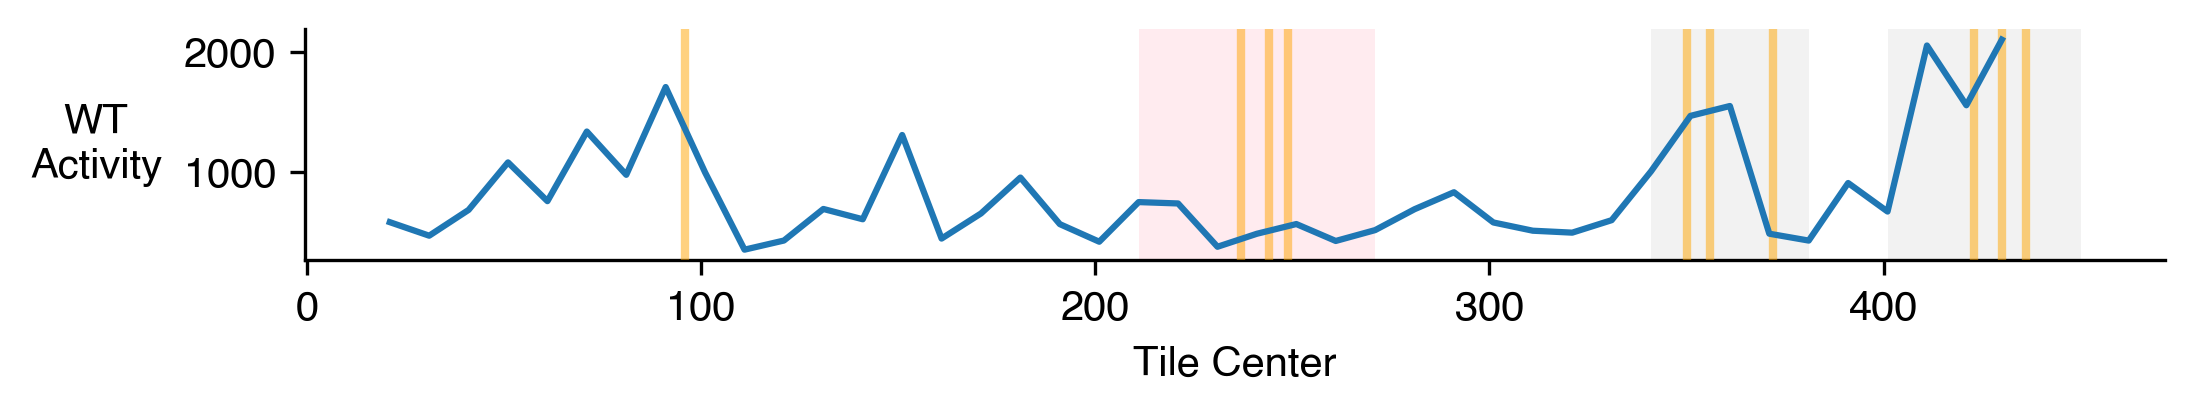

In [11]:
plot_wt_and_ps()
plt.axvspan(211, 271, facecolor='pink', alpha=0.3, label='Region A', zorder = 0)
plt.axvspan(341, 381, facecolor='silver', alpha=0.2, label='Region A', zorder = 0)
plt.axvspan(401, 450, facecolor='silver', alpha=0.2, label='Region A', zorder = 0)

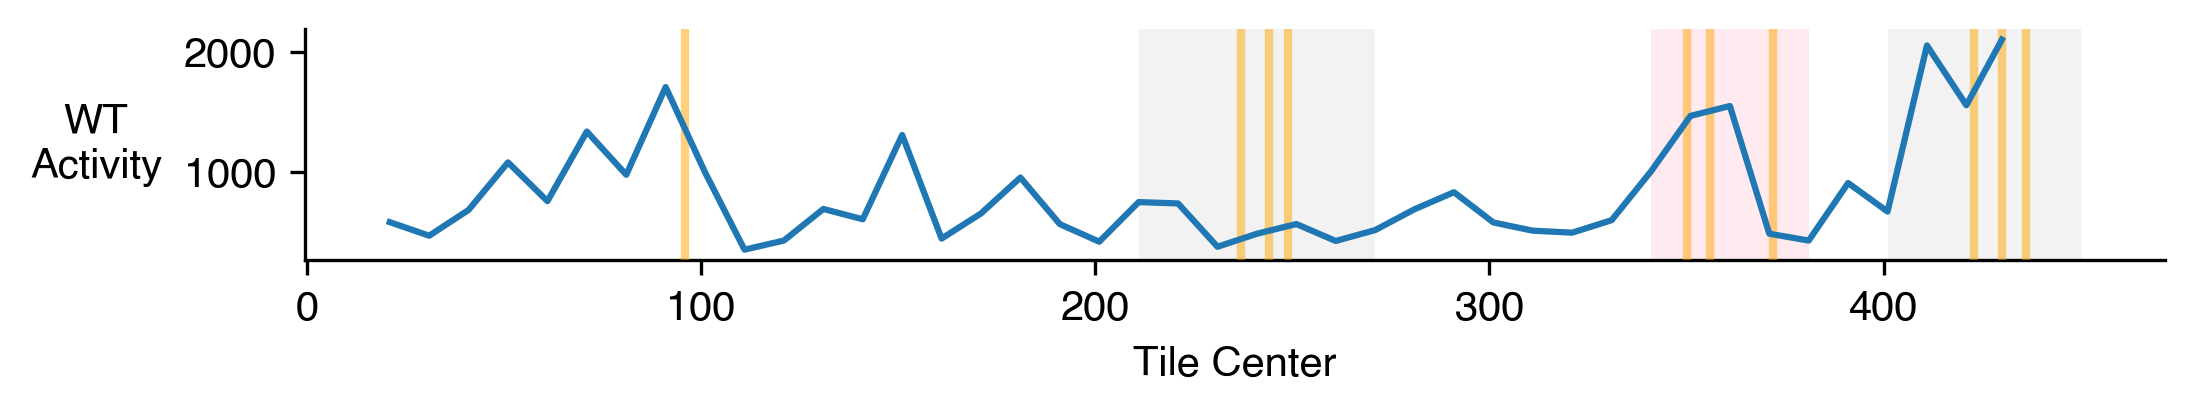

In [12]:
plot_wt_and_ps()
plt.axvspan(211, 271, facecolor='silver', alpha=0.2, label='Region A', zorder = 0)
plt.axvspan(341, 381, facecolor='pink', alpha=0.3, label='Region A', zorder = 0)
plt.axvspan(401, 450, facecolor='silver', alpha=0.2, label='Region A', zorder = 0)

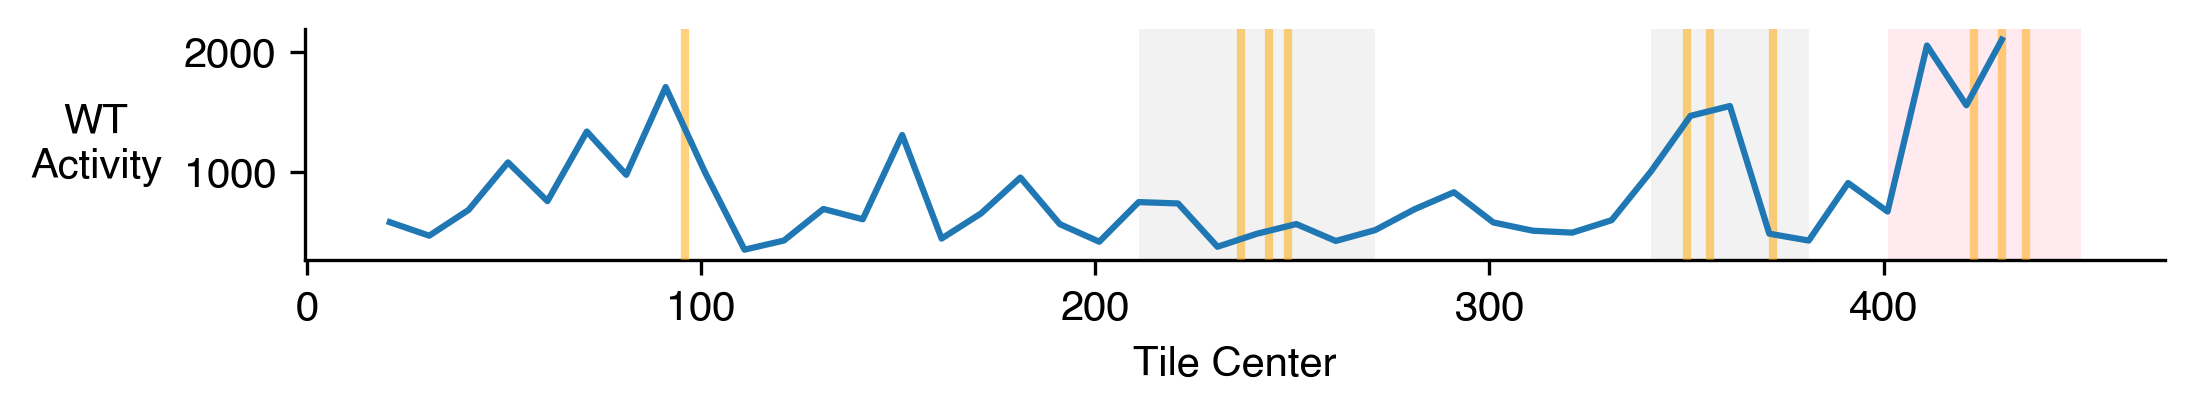

In [13]:
plot_wt_and_ps()
plt.axvspan(211, 271, facecolor='silver', alpha=0.2, label='Region A', zorder = 0)
plt.axvspan(341, 381, facecolor='silver', alpha=0.2, label='Region A', zorder = 0)
plt.axvspan(401, 450, facecolor='pink', alpha=0.3, label='Region A', zorder = 0)

# 1. How do mutants & mimetics of all confirmed phosphosites affect activity?

In [14]:
BasicArTh.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211


In [15]:
# Full confirmed phosphomutant tiles
PSv_conf2fA_STYA = sog1_helpers.return_activities("PSv_conf2fA_STYA")
PSv_conf2fA_STYA.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,61,100,7_PSv_conf2fA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,3015.0,426.984921,149.064628,2.0,277.920292,576.049549
1,71,110,8_PSv_conf2fA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,NaN,NaN,NaN,NaN,NaN,NaN
2,81,120,9_PSv_conf2fA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,4661.0,813.550909,NaN,1.0,NaN,NaN


In [16]:
# Full confirmed phosphomimetic tiles
PSv_conf2fD = sog1_helpers.return_activities("PSv_conf2fD")
PSv_conf2fD = PSv_conf2fD[~PSv_conf2fD["Description"].str.contains("DD")]
PSv_conf2fD.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,61,100,7_PSv_conf2fD,/,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPDVNQD,NaN,NaN,NaN,NaN,NaN,NaN
1,71,110,8_PSv_conf2fD,/,91,IIWHLLAKSGLSGLSSHPFIDEFIPDVNQDDGICYTHPKN,NaN,NaN,NaN,NaN,NaN,NaN
2,81,120,9_PSv_conf2fD,/,101,LSGLSSHPFIDEFIPDVNQDDGICYTHPKNLPGVKSDGTV,4663.0,1839.588076,1475.536928,3.0,364.051149,3315.125004


In [17]:
# Comparison to WT
PSv_conf2fA_STYA_vs_basic = sog1_helpers.add_all_var_positions(PSv_conf2fA_STYA, BasicArTh, activity_col)
PSv_conf2fD_vs_basic = sog1_helpers.add_all_var_positions(PSv_conf2fD, BasicArTh, activity_col)

In [18]:
phosphomut_positions = PSv_conf2fA_STYA_vs_basic.explode("vars")[["vars", activity_col + "_var"]].reset_index(drop = True)
phosphomim_positions = PSv_conf2fD_vs_basic.explode("vars")[["vars", activity_col + "_var"]].reset_index(drop = True)

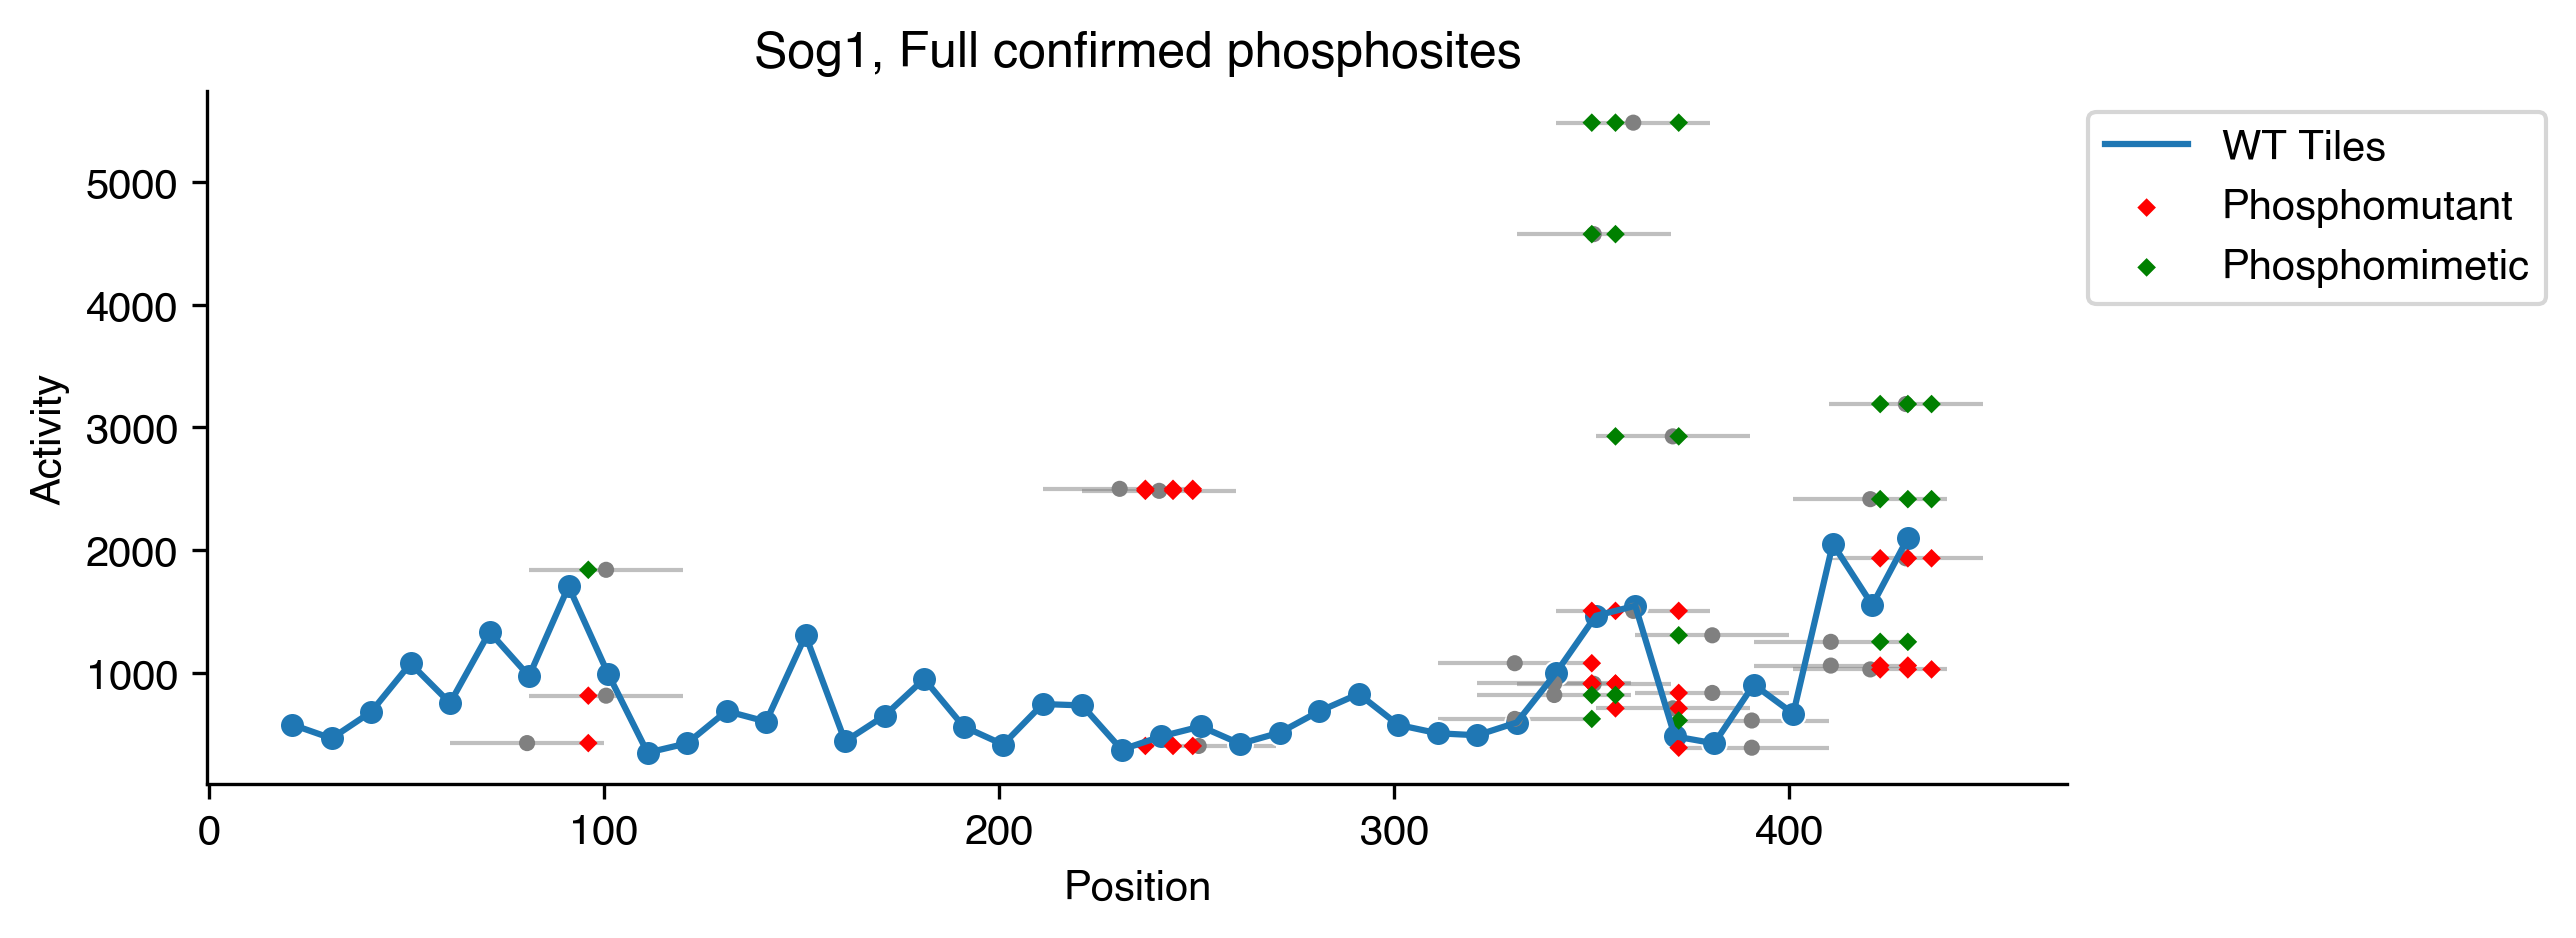

In [19]:
plt.figure(figsize = (8, 3), dpi = 300)
ax = sns.lineplot(data = BasicArTh, x = "mid", y = activity_col, label = "WT Tiles")
sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col)

#sns.lineplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, label = "Phosphomutant", color = "red")

#sns.lineplot(data = PSv_conf2fD, x = "mid", y = activity_col, label = "Phosphomimetic", color = "green")

sog1_helpers.plot_all_tiles(PSv_conf2fA_STYA, activity_col, ax=ax, color='gray', center = True)
sns.scatterplot(data = phosphomut_positions, x = "vars", y = activity_col + "_var", 
                ax = ax, color = "red", marker = "D", edgecolor = "none", s = 10, label = "Phosphomutant")

sog1_helpers.plot_all_tiles(PSv_conf2fD, activity_col, ax=ax, color='gray', center = True)
sns.scatterplot(data = phosphomim_positions, x = "vars", y = activity_col + "_var", 
                ax = ax, color = "green", marker = "D", edgecolor = "none", s = 10, label = "Phosphomimetic")

plt.title("Sog1, Full confirmed phosphosites")
plt.ylabel("Activity")
plt.xlabel("Position")
plt.legend(bbox_to_anchor = (1,1))
sns.despine()

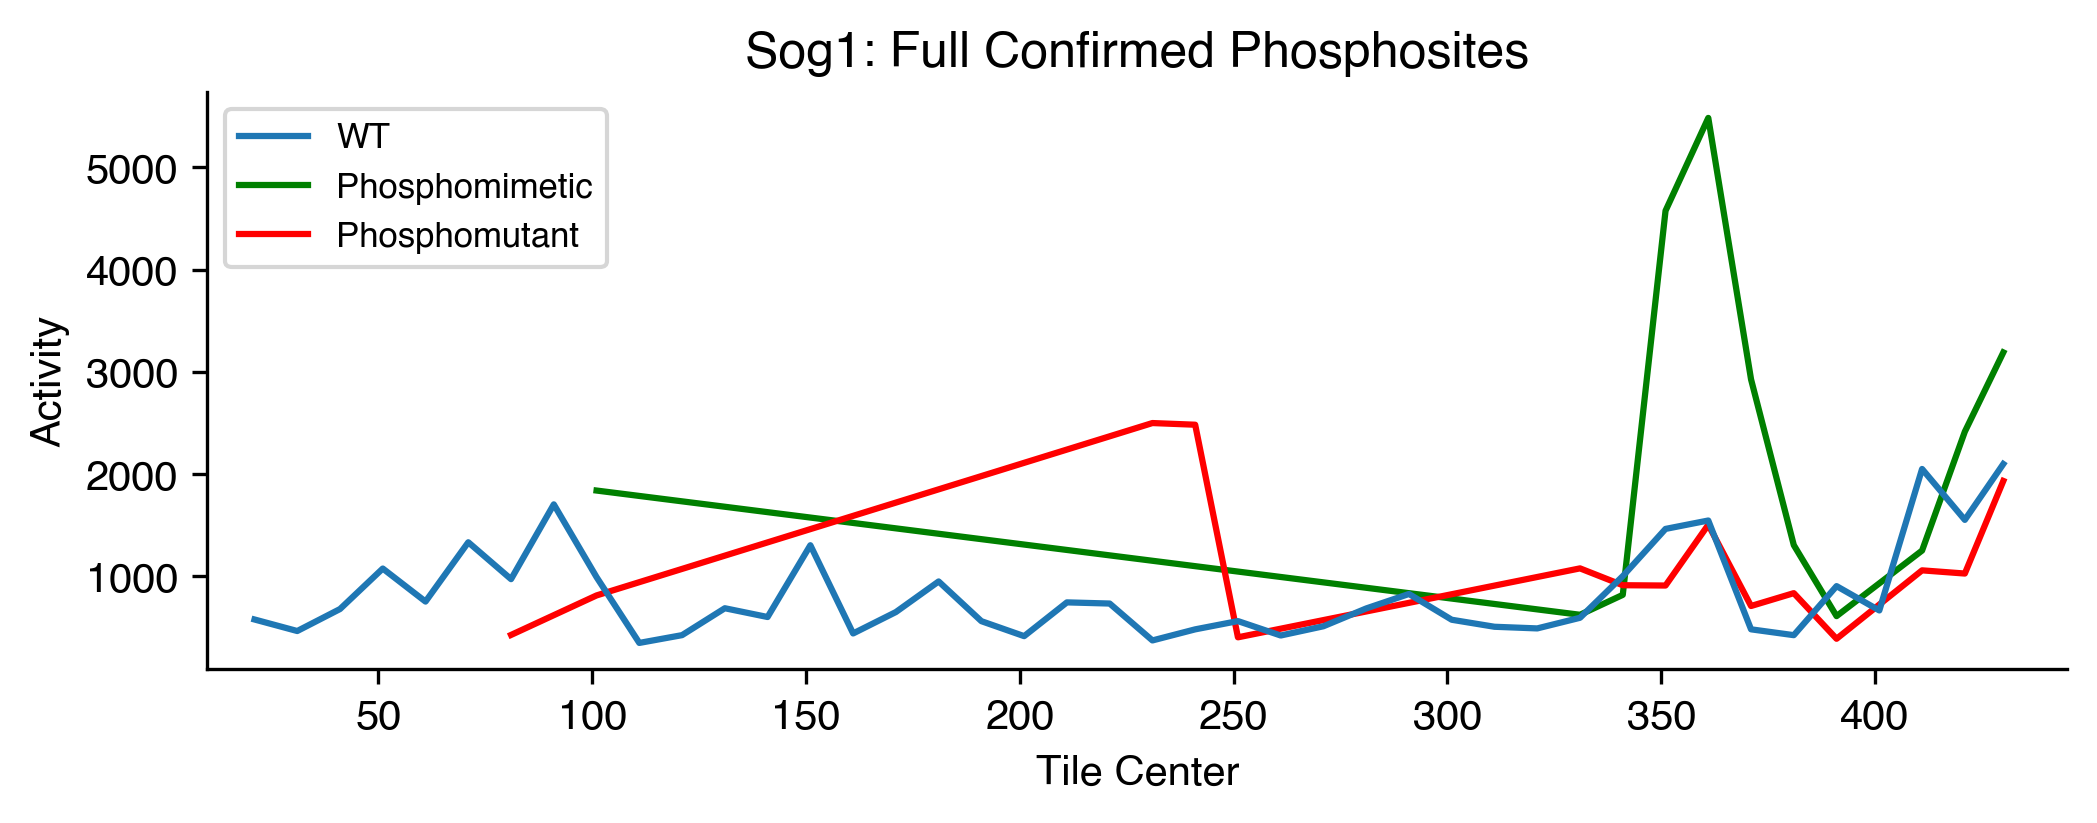

In [20]:
plt.figure(figsize = (8, 2.5), dpi = 300)
#plt.grid(zorder = 0)

# for i in np.arange(21, 440, 10):
#     plt.axvline(i, color = "gray", alpha = 0.1)

ax = sns.lineplot(data = BasicArTh, x = "mid", y = activity_col, zorder = 5, label = "WT")
#sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col, label = "WT", zorder = 5, edgecolor = "none")

#sns.lineplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, label = "Phosphomutant", color = "red")

#sns.lineplot(data = PSv_conf2fD, x = "mid", y = activity_col, label = "Phosphomimetic", color = "green")

# sog1_helpers.plot_all_tiles(PSv_conf2fA_STYA, activity_col, ax=ax, color='gray', center = True)
# sns.scatterplot(data = phosphomut_positions, x = "vars", y = activity_col + "_var", 
#                 ax = ax, color = "red", marker = "D", edgecolor = "none", s = 10, label = "Phosphomutant")

# sog1_helpers.plot_all_tiles(PSv_conf2fD, activity_col, ax=ax, color='gray', center = True)
# sns.scatterplot(data = phosphomim_positions, x = "vars", y = activity_col + "_var", 
#                 ax = ax, color = "green", marker = "D", edgecolor = "none", s = 10, label = "Phosphomimetic")

sns.lineplot(data = PSv_conf2fD, x = "mid", y = activity_col, label = "Phosphomimetic", color = "green")
sns.lineplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, label = "Phosphomutant", color = "red")

plt.xlim(10, 445)

plt.title("Sog1: Full Confirmed Phosphosites")
plt.ylabel("Activity")
plt.xlabel("Tile Center")
plt.legend(loc = "upper left", fontsize = "small")
sns.despine()

# 2. What is the order of importance of phosphosites?

## 2A. For each single confirmed phosphosite, how does WT vs STY-->A vs STY-->D activity compare?

In [21]:
PSv_conf2sA_STYA = sog1_helpers.return_activities('PSv_conf2sA_STYA')
PSv_conf2sA_STYA

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,61,100,7_PSv_conf2sA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,3015.0,426.984921,149.064628,2.0,277.920292,576.049549
1,71,110,8_PSv_conf2sA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,NaN,NaN,NaN,NaN,NaN,NaN
2,81,120,9_PSv_conf2sA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,4661.0,813.550909,NaN,1.0,NaN,NaN
3,91,130,10_PSv_conf2sA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,NaN,NaN,NaN,NaN,NaN,NaN
4,201,240,21_PSv_conf2sA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,NaN,NaN,NaN,NaN,NaN,NaN
5,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLATP,6071.0,364.801354,NaN,1.0,NaN,NaN
6,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLATP,6089.0,444.819567,289.054651,14.0,155.764916,733.874219
7,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLAAP,NaN,NaN,NaN,NaN,NaN,NaN
8,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVTPKLATPEPRNAVRICS,NaN,NaN,NaN,NaN,NaN,NaN
9,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVTPTADPVAPKLATPEPRNAVRICS,2702.0,1290.828938,1757.781941,9.0,-466.953003,3048.610879


In [22]:
PSv_conf2sA_STYA_vs_basic = sog1_helpers.add_var_positions(PSv_conf2sA_STYA, BasicArTh, activity_col)
PSv_conf2sA_STYA_vs_basic

,Start,End,Description_var,Other_var,mid,tile_var,Unnamed: 0_var,Activity_S3_1_var,Error_var,BC Count_var,...,Unnamed: 0_wt,Activity_S3_1_wt,Error_wt,BC Count_wt,activ_err_start_wt,activ_err_end_wt,var,activ_diff,activ_fold_change,signif_diff
0,61,100,7_PSv_conf2sA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,3015.0,426.984921,149.064628,2.0,...,3019,972.904562,473.415780,11,499.488782,1446.320342,96,-545.919642,0.438876,False
1,71,110,8_PSv_conf2sA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,NaN,NaN,NaN,NaN,...,3388,1704.401088,2314.845287,15,-610.444198,4019.246375,96,NaN,NaN,True
2,81,120,9_PSv_conf2sA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,4661.0,813.550909,NaN,1.0,...,4676,992.490299,1209.571573,18,-217.081274,2202.061872,96,-178.939391,0.819707,True
3,91,130,10_PSv_conf2sA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,NaN,NaN,NaN,NaN,...,411,348.974668,137.172549,8,211.802119,486.147217,96,NaN,NaN,True
4,201,240,21_PSv_conf2sA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,NaN,NaN,NaN,NaN,...,2749,734.130758,1318.626466,16,-584.495708,2052.757224,237,NaN,NaN,True
5,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLATP,6071.0,364.801354,NaN,1.0,...,6098,373.236751,229.121798,11,144.114953,602.358549,237,-8.435397,0.977399,True
6,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLATP,6089.0,444.819567,289.054651,14.0,...,6098,373.236751,229.121798,11,144.114953,602.358549,244,71.582816,1.191789,False
7,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLAAP,NaN,NaN,NaN,NaN,...,6098,373.236751,229.121798,11,144.114953,602.358549,249,NaN,NaN,True
8,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVTPKLATPEPRNAVRICS,NaN,NaN,NaN,NaN,...,2709,481.622237,195.657698,8,285.964539,677.279935,237,NaN,NaN,True
9,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVTPTADPVAPKLATPEPRNAVRICS,2702.0,1290.828938,1757.781941,9.0,...,2709,481.622237,195.657698,8,285.964539,677.279935,244,809.206701,2.680169,False


In [23]:
PSv_conf2sD = sog1_helpers.return_activities("PSv_conf2sD")
PSv_conf2sD = PSv_conf2sD[~PSv_conf2sD["Description"].str.contains("DD")]
PSv_conf2sD.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,61,100,7_PSv_conf2sD,/,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPDVNQD,NaN,NaN,NaN,NaN,NaN,NaN
1,71,110,8_PSv_conf2sD,/,91,IIWHLLAKSGLSGLSSHPFIDEFIPDVNQDDGICYTHPKN,NaN,NaN,NaN,NaN,NaN,NaN
2,81,120,9_PSv_conf2sD,/,101,LSGLSSHPFIDEFIPDVNQDDGICYTHPKNLPGVKSDGTV,4663.0,1839.588076,1475.536928,3.0,364.051149,3315.125004


In [24]:
PSv_conf2sD_vs_basic = sog1_helpers.add_var_positions(PSv_conf2sD, BasicArTh, activity_col)
PSv_conf2sD_vs_basic

,Start,End,Description_var,Other_var,mid,tile_var,Unnamed: 0_var,Activity_S3_1_var,Error_var,BC Count_var,...,Unnamed: 0_wt,Activity_S3_1_wt,Error_wt,BC Count_wt,activ_err_start_wt,activ_err_end_wt,var,activ_diff,activ_fold_change,signif_diff
0,61,100,7_PSv_conf2sD,/,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPDVNQD,NaN,NaN,NaN,NaN,...,3019,972.904562,473.415780,11,499.488782,1446.320342,96,NaN,NaN,True
1,71,110,8_PSv_conf2sD,/,91,IIWHLLAKSGLSGLSSHPFIDEFIPDVNQDDGICYTHPKN,NaN,NaN,NaN,NaN,...,3388,1704.401088,2314.845287,15,-610.444198,4019.246375,96,NaN,NaN,True
2,81,120,9_PSv_conf2sD,/,101,LSGLSSHPFIDEFIPDVNQDDGICYTHPKNLPGVKSDGTV,4663.0,1839.588076,1475.536928,3.0,...,4676,992.490299,1209.571573,18,-217.081274,2202.061872,96,847.097777,1.853507,False
3,91,130,10_PSv_conf2sD,/,111,DEFIPDVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,NaN,NaN,NaN,NaN,...,411,348.974668,137.172549,8,211.802119,486.147217,96,NaN,NaN,True
4,201,240,21_PSv_conf2sD,/,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVDPTA,NaN,NaN,NaN,NaN,...,2749,734.130758,1318.626466,16,-584.495708,2052.757224,237,NaN,NaN,True
5,211,250,22_PSv_conf2sD,/,231,QQPQQLVVKRGDKAEQEVSEDIFAAVDPTADPVTPKLATP,NaN,NaN,NaN,NaN,...,6098,373.236751,229.121798,11,144.114953,602.358549,237,NaN,NaN,True
6,211,250,22_PSv_conf2sD,/,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVDPKLATP,6091.0,1051.243553,1745.452628,10.0,...,6098,373.236751,229.121798,11,144.114953,602.358549,244,678.006802,2.816560,False
7,211,250,22_PSv_conf2sD,/,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLADP,6094.0,505.964683,NaN,1.0,...,6098,373.236751,229.121798,11,144.114953,602.358549,249,132.727932,1.355613,True
8,221,260,23_PSv_conf2sD,/,241,GDKAEQEVSEDIFAAVDPTADPVTPKLATPEPRNAVRICS,2688.0,3784.657037,NaN,1.0,...,2709,481.622237,195.657698,8,285.964539,677.279935,237,3303.034799,7.858144,True
9,221,260,23_PSv_conf2sD,/,241,GDKAEQEVSEDIFAAVTPTADPVDPKLATPEPRNAVRICS,2704.0,396.549787,127.350664,9.0,...,2709,481.622237,195.657698,8,285.964539,677.279935,244,-85.072450,0.823363,False


In [25]:
conf_s_A_D = pd.merge(PSv_conf2sA_STYA_vs_basic, PSv_conf2sD_vs_basic, on = ["Start", "mid", "End", "var"], suffixes = ("_A", "_D"))
conf_s_A_D

,Start,End,Description_var_A,Other_var_A,mid,tile_var_A,Unnamed: 0_var_A,Activity_S3_1_var_A,Error_var_A,BC Count_var_A,...,tile_wt_D,Unnamed: 0_wt_D,Activity_S3_1_wt_D,Error_wt_D,BC Count_wt_D,activ_err_start_wt_D,activ_err_end_wt_D,activ_diff_D,activ_fold_change_D,signif_diff_D
0,61,100,7_PSv_conf2sA_STYA,NaN,81,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPAVNQD,3015.0,426.984921,149.064628,2.0,...,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQD,3019,972.904562,473.415780,11,499.488782,1446.320342,NaN,NaN,True
1,71,110,8_PSv_conf2sA_STYA,NaN,91,IIWHLLAKSGLSGLSSHPFIDEFIPAVNQDDGICYTHPKN,NaN,NaN,NaN,NaN,...,IIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKN,3388,1704.401088,2314.845287,15,-610.444198,4019.246375,NaN,NaN,True
2,81,120,9_PSv_conf2sA_STYA,NaN,101,LSGLSSHPFIDEFIPAVNQDDGICYTHPKNLPGVKSDGTV,4661.0,813.550909,NaN,1.0,...,LSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTV,4676,992.490299,1209.571573,18,-217.081274,2202.061872,847.097777,1.853507,False
3,91,130,10_PSv_conf2sA_STYA,NaN,111,DEFIPAVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,NaN,NaN,NaN,NaN,...,DEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,411,348.974668,137.172549,8,211.802119,486.147217,NaN,NaN,True
4,201,240,21_PSv_conf2sA_STYA,NaN,221,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVAPTA,NaN,NaN,NaN,NaN,...,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVTPTA,2749,734.130758,1318.626466,16,-584.495708,2052.757224,NaN,NaN,True
5,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVAPTADPVTPKLATP,6071.0,364.801354,NaN,1.0,...,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,6098,373.236751,229.121798,11,144.114953,602.358549,NaN,NaN,True
6,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVAPKLATP,6089.0,444.819567,289.054651,14.0,...,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,6098,373.236751,229.121798,11,144.114953,602.358549,678.006802,2.816560,False
7,211,250,22_PSv_conf2sA_STYA,NaN,231,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLAAP,NaN,NaN,NaN,NaN,...,QQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATP,6098,373.236751,229.121798,11,144.114953,602.358549,132.727932,1.355613,True
8,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVAPTADPVTPKLATPEPRNAVRICS,NaN,NaN,NaN,NaN,...,GDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICS,2709,481.622237,195.657698,8,285.964539,677.279935,3303.034799,7.858144,True
9,221,260,23_PSv_conf2sA_STYA,NaN,241,GDKAEQEVSEDIFAAVTPTADPVAPKLATPEPRNAVRICS,2702.0,1290.828938,1757.781941,9.0,...,GDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICS,2709,481.622237,195.657698,8,285.964539,677.279935,-85.072450,0.823363,False


In [26]:

conf_s_A_D["log_activ_fold_change_D"] = np.log(conf_s_A_D["activ_fold_change_D"])
conf_s_A_D["log_activ_fold_change_A"] = np.log(conf_s_A_D["activ_fold_change_A"])

pos_avgs = conf_s_A_D[["var", "log_activ_fold_change_D", "log_activ_fold_change_A"]].groupby("var").mean()
pos_avgs = pos_avgs.reset_index()
pos_avgs

,var,log_activ_fold_change_D,log_activ_fold_change_A
0,96,0.617080,-0.511173
1,237,1.150163,-0.165311
2,244,0.253329,0.358953
3,249,0.376680,1.115929
4,350,-0.156776,-0.088434
5,356,0.582775,-0.225394
6,372,0.493386,-0.003587
7,423,0.064650,-0.193901
8,430,0.025633,0.109569
9,436,0.274026,0.160348


<Figure size 2400x450 with 0 Axes>

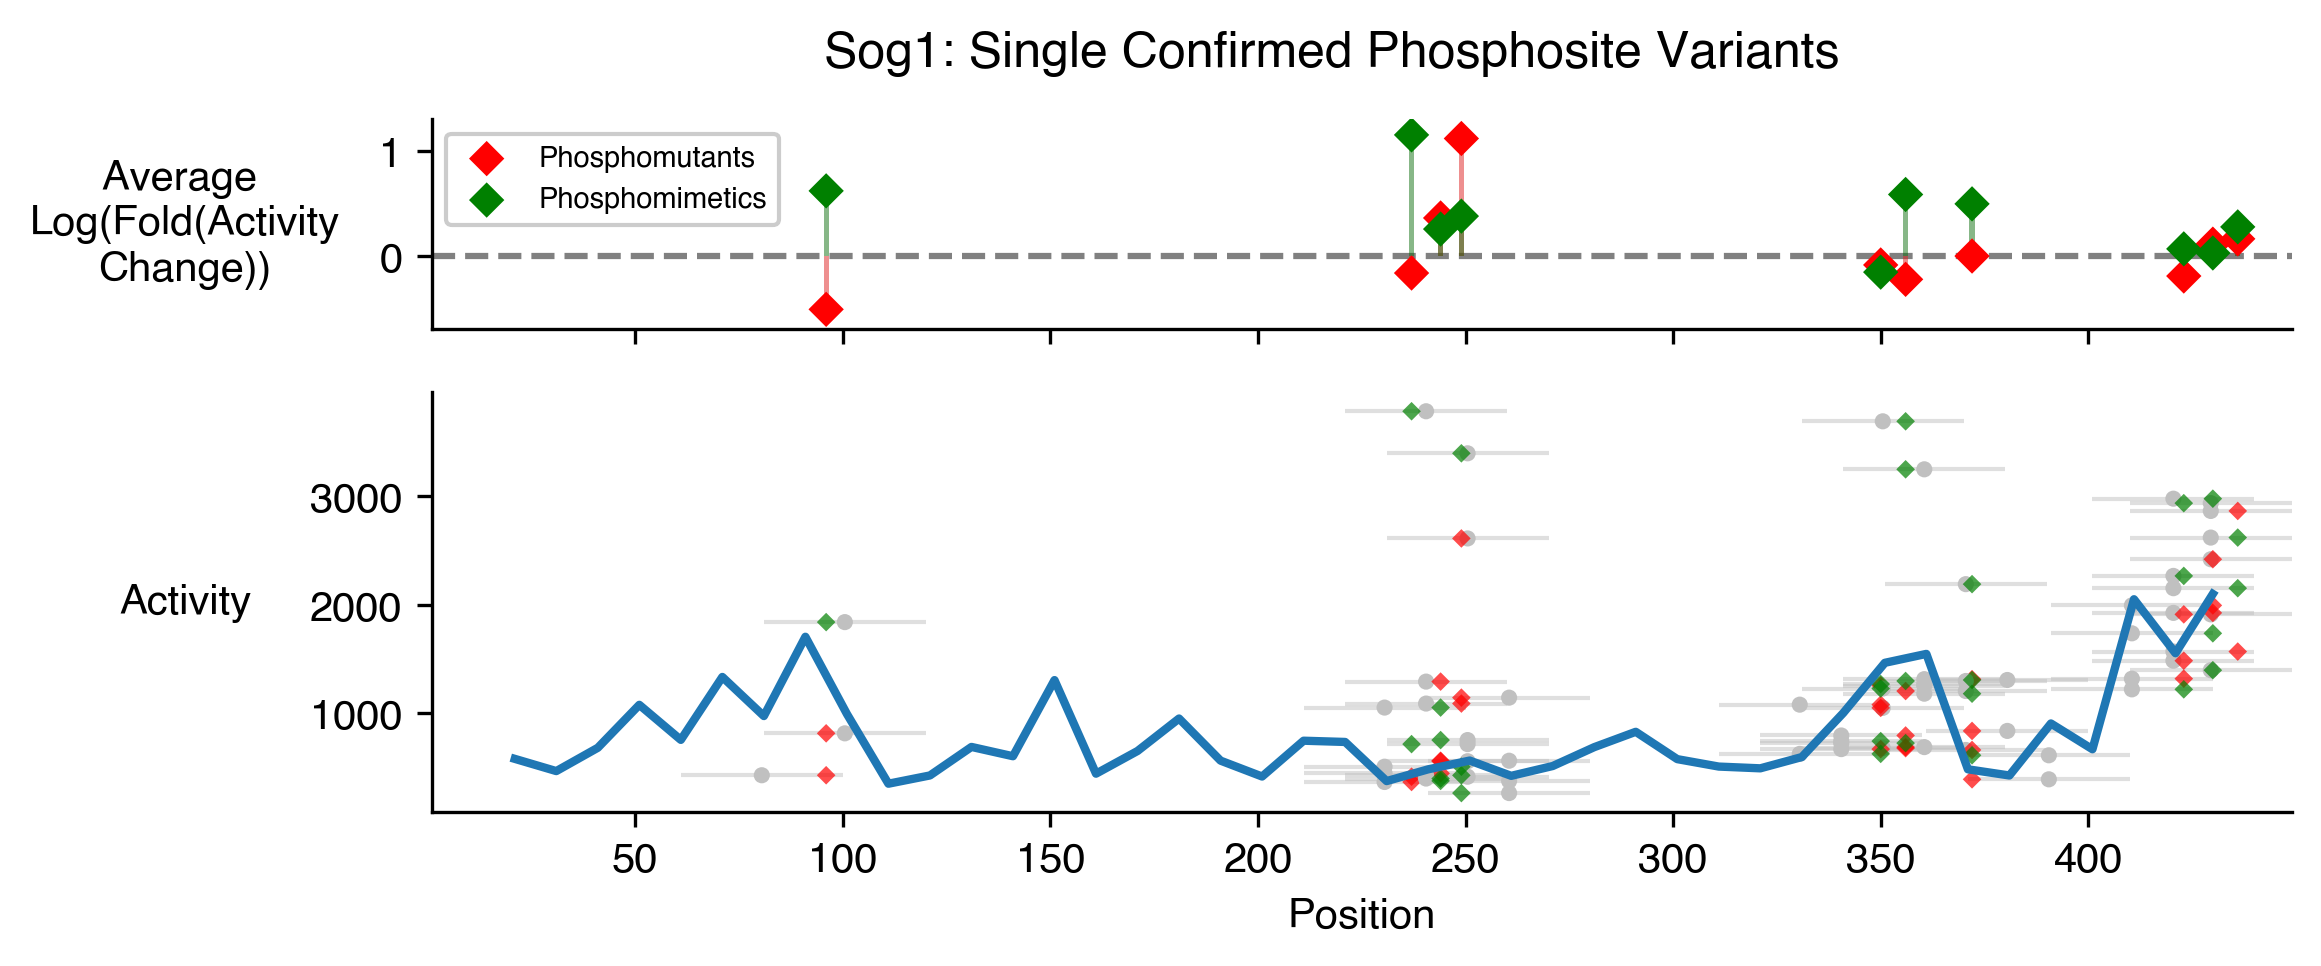

In [27]:
plt.figure(figsize = (8, 1.5), dpi = 300)


fig, axs = plt.subplots(2, 1, figsize=(8, 3), sharex=True, gridspec_kw = {'height_ratios' : [1, 2]}, dpi = 300)

# Plot part 1
ps_locs = sog1_aa_features[sog1_aa_features["PS"]]


# for pos in ps_locs["pos"]:
#     axs[0].axvline(pos, color = "gray", zorder = 0, alpha = 0.2, lw = 2)


# sns.scatterplot(data = conf_s_A_D, x = "var", y = "log_activ_fold_change_A", color = "red", alpha = 0.5, edgecolor = 'none', s = 10)
# sns.scatterplot(data = conf_s_A_D, x = "var", y = "log_activ_fold_change_D", color = "green", alpha = 0.5, edgecolor = 'none', s = 10)

sns.barplot(data=pos_avgs, 
                x="var", 
                y="log_activ_fold_change_A", 
                legend=False, 
                alpha=0.5, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0], color = "red", width = 0.25)



sns.barplot(data=pos_avgs, 
                x="var", 
                y="log_activ_fold_change_D", 
                legend=False, 
                alpha=0.5, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0], color = "green", width = 0.25)

sns.scatterplot(data = pos_avgs, x = "var", y = "log_activ_fold_change_A", color = "red", marker = "D", lw = 1, edgecolor = 'none', ax = axs[0], 
                label = "Phosphomutants")
sns.scatterplot(data = pos_avgs, x = "var", y = "log_activ_fold_change_D", color = "green", marker = "D", lw = 1, edgecolor = 'none', ax = axs[0], 
                label = "Phosphomimetics")

#axs[0].legend(bbox_to_anchor = (1, 1), fontsize = "small")
axs[0].legend(loc = "upper left", fontsize = "x-small", framealpha = 1)

#axs[0].text(x = 0, y = 1, s = "Phosphomutants ($\\rightarrow$A)", color = "red")

# Plot part 2
sog1_helpers.plot_all_tiles(PSv_conf2sA_STYA_vs_basic, activity_col + "_var", ax=axs[1], color='silver')
sns.scatterplot(data=PSv_conf2sA_STYA_vs_basic, 
                x="var", 
                y=activity_col + "_var", 
                color="red", 
                legend=False, 
                alpha=0.7, ax=axs[1], marker = "D", edgecolor = "none", s = 10)

sog1_helpers.plot_all_tiles(PSv_conf2sD_vs_basic, activity_col + "_var", ax=axs[1], color='silver')
sns.scatterplot(data=PSv_conf2sD_vs_basic, 
                x="var", 
                y=activity_col + "_var", 
                color="green", 
                legend=False, 
                alpha=0.7, ax=axs[1], marker = "D", edgecolor = "none", s = 10)

sns.lineplot(data=BasicArTh, x="mid", y=activity_col, label="WT Tiles", lw=2, ax=axs[1], legend = False)


axs[0].axhline(0, color = "gray", zorder = 0, linestyle = "--")
axs[0].set_ylabel("Average \nLog(Fold(Activity\nChange))", rotation = 0, labelpad = 30, va = 'center')
axs[0].set_ylim(-0.7, 1.3)

axs[1].set_xlim(1, 449)
axs[1].set_ylabel("Activity", rotation = 0, labelpad = 30, va = 'center')
axs[1].set_xlabel("Position")

sns.despine()

plt.suptitle("Sog1: Single Confirmed Phosphosite Variants")

fig.align_ylabels(axs)


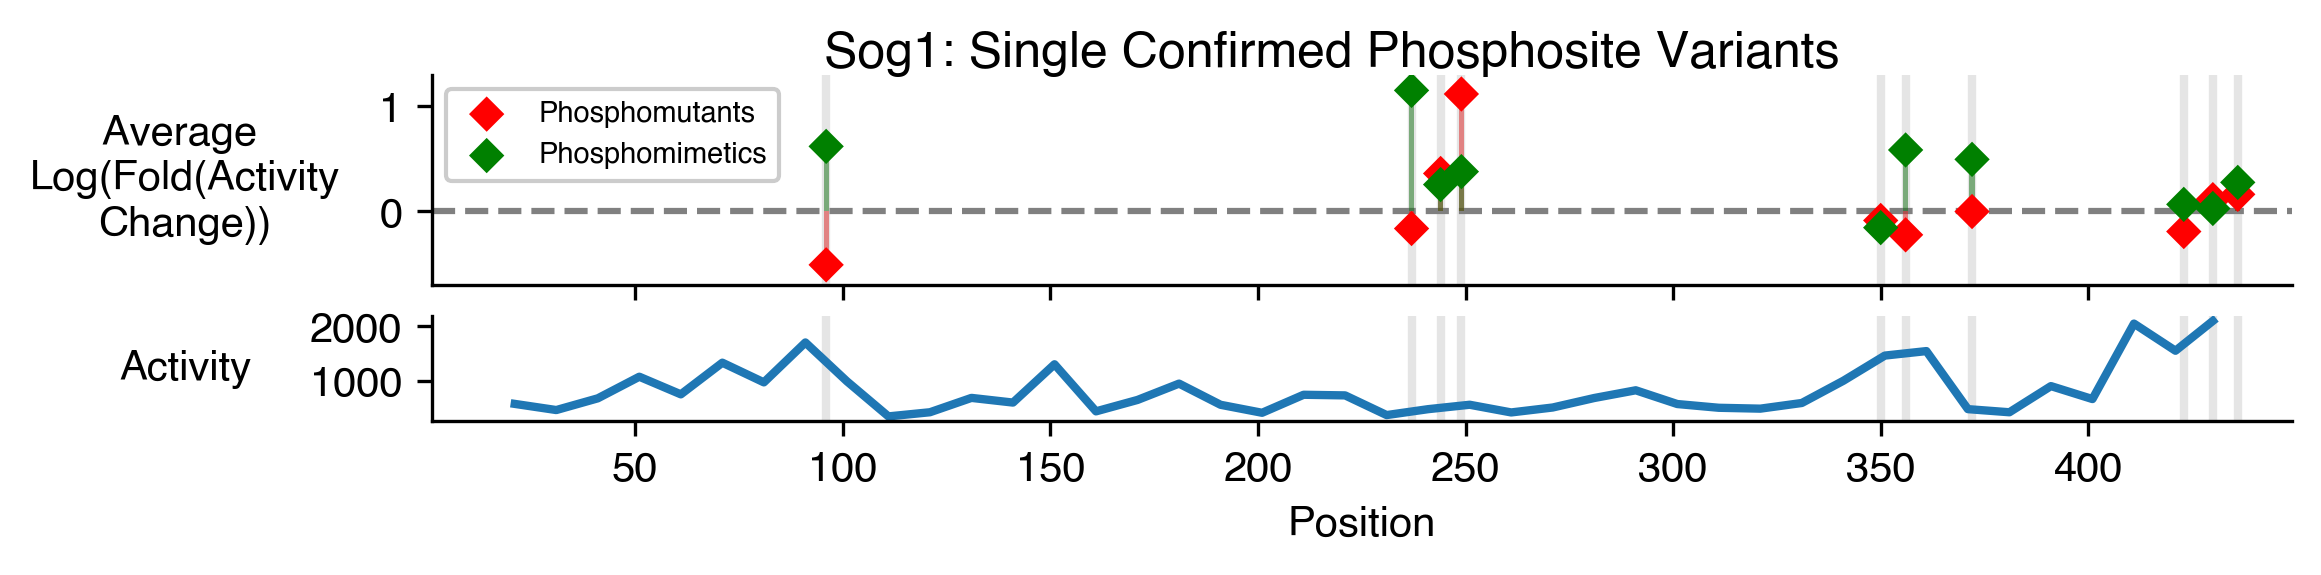

In [28]:
fig, axs = plt.subplots(2, 1, figsize=(8, 1.5), sharex=True, gridspec_kw = {'height_ratios' : [2, 1]}, dpi = 300)

# Plot part 1
ps_locs = sog1_aa_features[sog1_aa_features["PS"]]
for pos in ps_locs["pos"]:
    axs[0].axvline(pos, color = "gray", zorder = 0, alpha = 0.2, lw = 2)



# sns.scatterplot(data = conf_s_A_D, x = "var", y = "log_activ_fold_change_A", color = "red", alpha = 0.5, edgecolor = 'none', s = 10)
# sns.scatterplot(data = conf_s_A_D, x = "var", y = "log_activ_fold_change_D", color = "green", alpha = 0.5, edgecolor = 'none', s = 10)

sns.barplot(data=pos_avgs, 
                x="var", 
                y="log_activ_fold_change_A", 
                legend=False, 
                alpha=0.5, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0], color = "red", width = 0.25)



sns.barplot(data=pos_avgs, 
                x="var", 
                y="log_activ_fold_change_D", 
                legend=False, 
                alpha=0.5, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0], color = "green", width = 0.25)

sns.scatterplot(data = pos_avgs, x = "var", y = "log_activ_fold_change_A", color = "red", marker = "D", lw = 1, edgecolor = 'none', ax = axs[0], 
                label = "Phosphomutants")
sns.scatterplot(data = pos_avgs, x = "var", y = "log_activ_fold_change_D", color = "green", marker = "D", lw = 1, edgecolor = 'none', ax = axs[0], 
                label = "Phosphomimetics")

#axs[0].legend(bbox_to_anchor = (1, 1), fontsize = "small")
axs[0].legend(loc = "upper left", fontsize = "x-small", framealpha = 1)

#axs[0].text(x = 0, y = 1, s = "Phosphomutants ($\\rightarrow$A)", color = "red")

# Plot part 2
for pos in ps_locs["pos"]:
    axs[1].axvline(pos, color = "gray", zorder = 0, alpha = 0.2, lw = 2)

sns.lineplot(data=BasicArTh, x="mid", y=activity_col, label="WT Tiles", lw=2, ax=axs[1], legend = False)


axs[0].axhline(0, color = "gray", zorder = 0, linestyle = "--")
axs[0].set_ylabel("Average \nLog(Fold(Activity\nChange))", rotation = 0, labelpad = 30, va = 'center')
axs[0].set_ylim(-0.7, 1.3)

axs[1].set_xlim(1, 449)
axs[1].set_ylabel("Activity", rotation = 0, labelpad = 30, va = 'center')
axs[1].set_xlabel("Position")

sns.despine()

plt.suptitle("Sog1: Single Confirmed Phosphosite Variants")

fig.align_ylabels(axs)





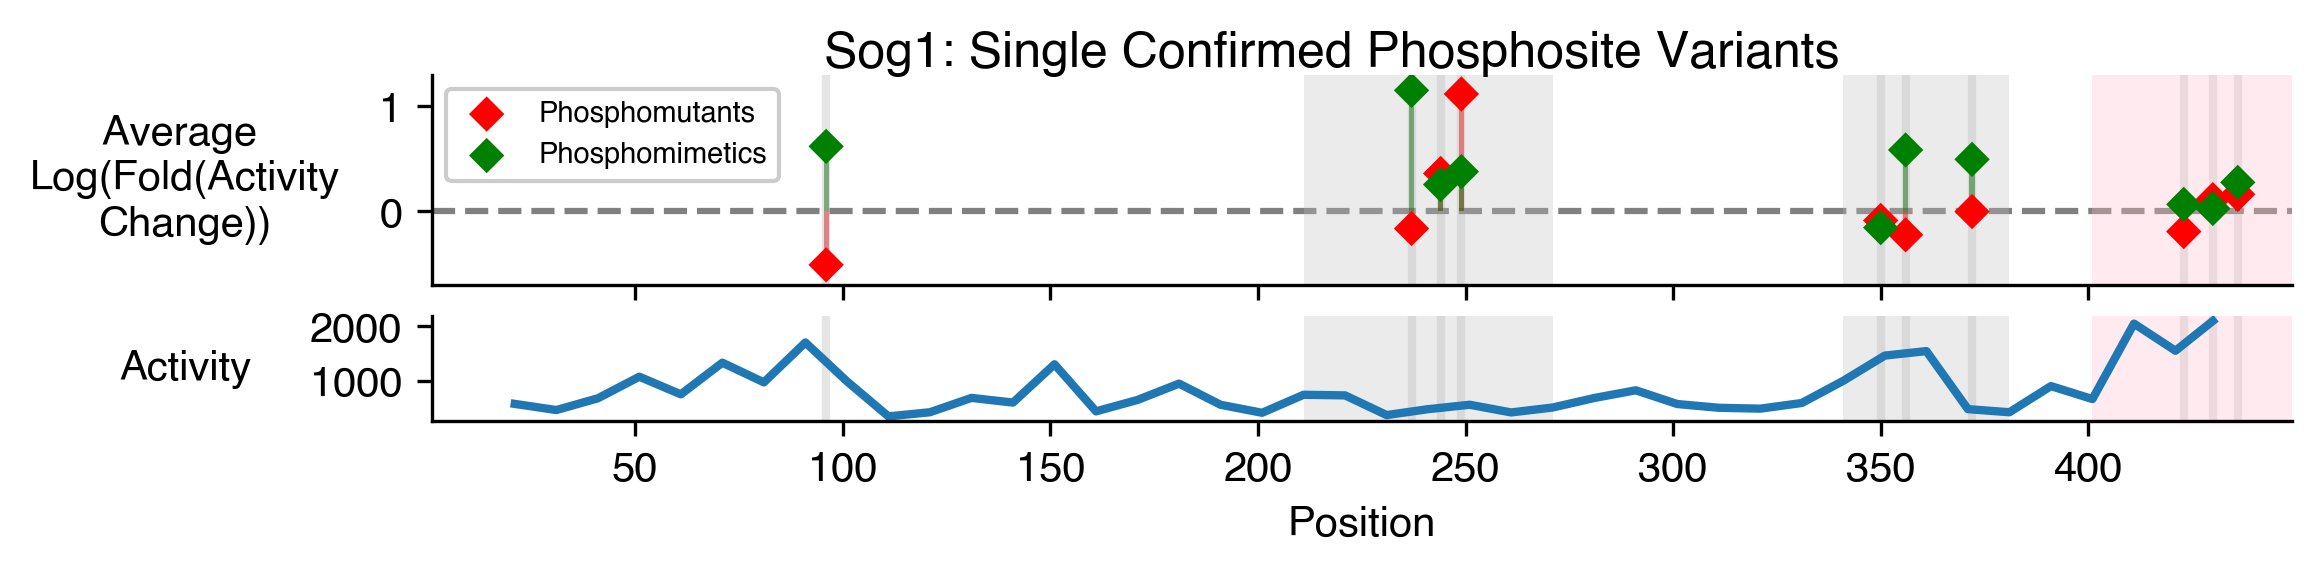

In [29]:
fig, axs = plt.subplots(2, 1, figsize=(8, 1.5), sharex=True, gridspec_kw = {'height_ratios' : [2, 1]}, dpi = 300)

# Plot part 1
ps_locs = sog1_aa_features[sog1_aa_features["PS"]]
for pos in ps_locs["pos"]:
    axs[0].axvline(pos, color = "gray", zorder = 0, alpha = 0.2, lw = 2)



# sns.scatterplot(data = conf_s_A_D, x = "var", y = "log_activ_fold_change_A", color = "red", alpha = 0.5, edgecolor = 'none', s = 10)
# sns.scatterplot(data = conf_s_A_D, x = "var", y = "log_activ_fold_change_D", color = "green", alpha = 0.5, edgecolor = 'none', s = 10)

sns.barplot(data=pos_avgs, 
                x="var", 
                y="log_activ_fold_change_A", 
                legend=False, 
                alpha=0.5, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0], color = "red", width = 0.25)



sns.barplot(data=pos_avgs, 
                x="var", 
                y="log_activ_fold_change_D", 
                legend=False, 
                alpha=0.5, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0], color = "green", width = 0.25)

sns.scatterplot(data = pos_avgs, x = "var", y = "log_activ_fold_change_A", color = "red", marker = "D", lw = 1, edgecolor = 'none', ax = axs[0], 
                label = "Phosphomutants")
sns.scatterplot(data = pos_avgs, x = "var", y = "log_activ_fold_change_D", color = "green", marker = "D", lw = 1, edgecolor = 'none', ax = axs[0], 
                label = "Phosphomimetics")

#axs[0].legend(bbox_to_anchor = (1, 1), fontsize = "small")
axs[0].legend(loc = "upper left", fontsize = "x-small", framealpha = 1)

#axs[0].text(x = 0, y = 1, s = "Phosphomutants ($\\rightarrow$A)", color = "red")

# Plot part 2
for pos in ps_locs["pos"]:
    axs[1].axvline(pos, color = "gray", zorder = 0, alpha = 0.2, lw = 2)

sns.lineplot(data=BasicArTh, x="mid", y=activity_col, label="WT Tiles", lw=2, ax=axs[1], legend = False)


axs[0].axhline(0, color = "gray", zorder = 0, linestyle = "--")
axs[0].set_ylabel("Average \nLog(Fold(Activity\nChange))", rotation = 0, labelpad = 30, va = 'center')
axs[0].set_ylim(-0.7, 1.3)

axs[1].set_xlim(1, 449)
axs[1].set_ylabel("Activity", rotation = 0, labelpad = 30, va = 'center')
axs[1].set_xlabel("Position")

sns.despine()

plt.suptitle("Sog1: Single Confirmed Phosphosite Variants")

fig.align_ylabels(axs)

axs[0].axvspan(211, 271, facecolor='silver', alpha=0.3, label='Region A', zorder = 0)
axs[1].axvspan(211, 271, facecolor='silver', alpha=0.3, label='Region A', zorder = 0)

axs[0].axvspan(341, 381, facecolor='silver', alpha=0.3, label='Region A', zorder = 0)
axs[1].axvspan(341, 381, facecolor='silver', alpha=0.3, label='Region A', zorder = 0)

axs[0].axvspan(401, 450, facecolor='pink', alpha=0.3, label='Region A', zorder = 0)
axs[1].axvspan(401, 450, facecolor='pink', alpha=0.3, label='Region A', zorder = 0)

# Compare confirmed to full

In [30]:
PSv_max2A_STYA = sog1_helpers.return_activities('PSv_max2A_STYA')
PSv_max2A_STYA

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,1,40,1_PSv_max2A_STYA,NaN,21,MAGRAWLIDANRIAAKIMAAAAAADPRQVVWKANPARHCP,NaN,NaN,NaN,NaN,NaN,NaN
1,11,50,2_PSv_max2A_STYA,NaN,31,NRIAAKIMAAAAAADPRQVVWKANPARHCPKCQHVIDNAD,4965.0,636.319554,361.348334,2.0,274.971221,997.667888
2,21,60,3_PSv_max2A_STYA,NaN,41,AAAADPRQVVWKANPARHCPKCQHVIDNADVVDDWPGLPR,NaN,NaN,NaN,NaN,NaN,NaN
3,31,70,4_PSv_max2A_STYA,NaN,51,WKANPARHCPKCQHVIDNADVVDDWPGLPRGVKFDPADPE,6691.0,313.982452,NaN,1.0,NaN,NaN
4,41,80,5_PSv_max2A_STYA,NaN,61,KCQHVIDNADVVDDWPGLPRGVKFDPADPEIIWHLLAKSG,NaN,NaN,NaN,NaN,NaN,NaN
5,51,90,6_PSv_max2A_STYA,NaN,71,VVDDWPGLPRGVKFDPADPEIIWHLLAKAGLAGLAAHPFI,6633.0,3119.255803,1722.521597,2.0,1396.734206,4841.777399
6,61,100,7_PSv_max2A_STYA,NaN,81,GVKFDPADPEIIWHLLAKAGLAGLAAHPFIDEFIPAVNQD,NaN,NaN,NaN,NaN,NaN,NaN
7,71,110,8_PSv_max2A_STYA,PS:Y(!)x1,91,IIWHLLAKAGLAGLAAHPFIDEFIPAVNQDDGICAAHPKN,3356.0,519.063964,NaN,1.0,NaN,NaN
8,81,120,9_PSv_max2A_STYA,PS:Y(!)x1,101,LAGLAAHPFIDEFIPAVNQDDGICAAHPKNLPGVKADGAV,NaN,NaN,NaN,NaN,NaN,NaN
9,91,130,10_PSv_max2A_STYA,PS:Y(!)x1,111,DEFIPAVNQDDGICAAHPKNLPGVKADGAVAHFFHKAIKA,395.0,4165.471997,NaN,1.0,NaN,NaN


In [31]:
PSv_max2D = sog1_helpers.return_activities('PSv_max2D')
PSv_max2D.at[35, "mid"] = 371
PSv_max2D

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,1,40,1_PSv_max2D,/,21,MAGRDWLIDDNRIADKIMDADADDDPRQVVWKDNPDRHCP,NaN,NaN,NaN,NaN,NaN,NaN
1,11,50,2_PSv_max2D,/,31,NRIADKIMDADADDDPRQVVWKDNPDRHCPKCQHVIDNDD,4967.0,229.277283,NaN,1.0,NaN,NaN
2,21,60,3_PSv_max2D,/,41,DADDDPRQVVWKDNPDRHCPKCQHVIDNDDVVDDWPGLPR,NaN,NaN,NaN,NaN,NaN,NaN
3,31,70,4_PSv_max2D,/,51,WKDNPDRHCPKCQHVIDNDDVVDDWPGLPRGVKFDPDDPE,6693.0,182.698710,NaN,1.0,NaN,NaN
4,41,80,5_PSv_max2D,/,61,KCQHVIDNDDVVDDWPGLPRGVKFDPDDPEIIWHLLAKSG,NaN,NaN,NaN,NaN,NaN,NaN
5,51,90,6_PSv_max2D,/,71,VVDDWPGLPRGVKFDPDDPEIIWHLLAKDGLDGLDDHPFI,NaN,NaN,NaN,NaN,NaN,NaN
6,61,100,7_PSv_max2D,/,81,GVKFDPDDPEIIWHLLAKDGLDGLDDHPFIDEFIPDVNQD,NaN,NaN,NaN,NaN,NaN,NaN
7,71,110,8_PSv_max2D,/,91,IIWHLLAKDGLDGLDDHPFIDEFIPDVNQDDGICDDHPKN,NaN,NaN,NaN,NaN,NaN,NaN
8,81,120,9_PSv_max2D,/,101,LDGLDDHPFIDEFIPDVNQDDGICDDHPKNLPGVKDDGDV,4419.0,5746.395913,NaN,1.0,NaN,NaN
9,91,130,10_PSv_max2D,/,111,DEFIPDVNQDDGICDDHPKNLPGVKDDGDVDHFFHKAIKA,398.0,1090.710566,NaN,1.0,NaN,NaN


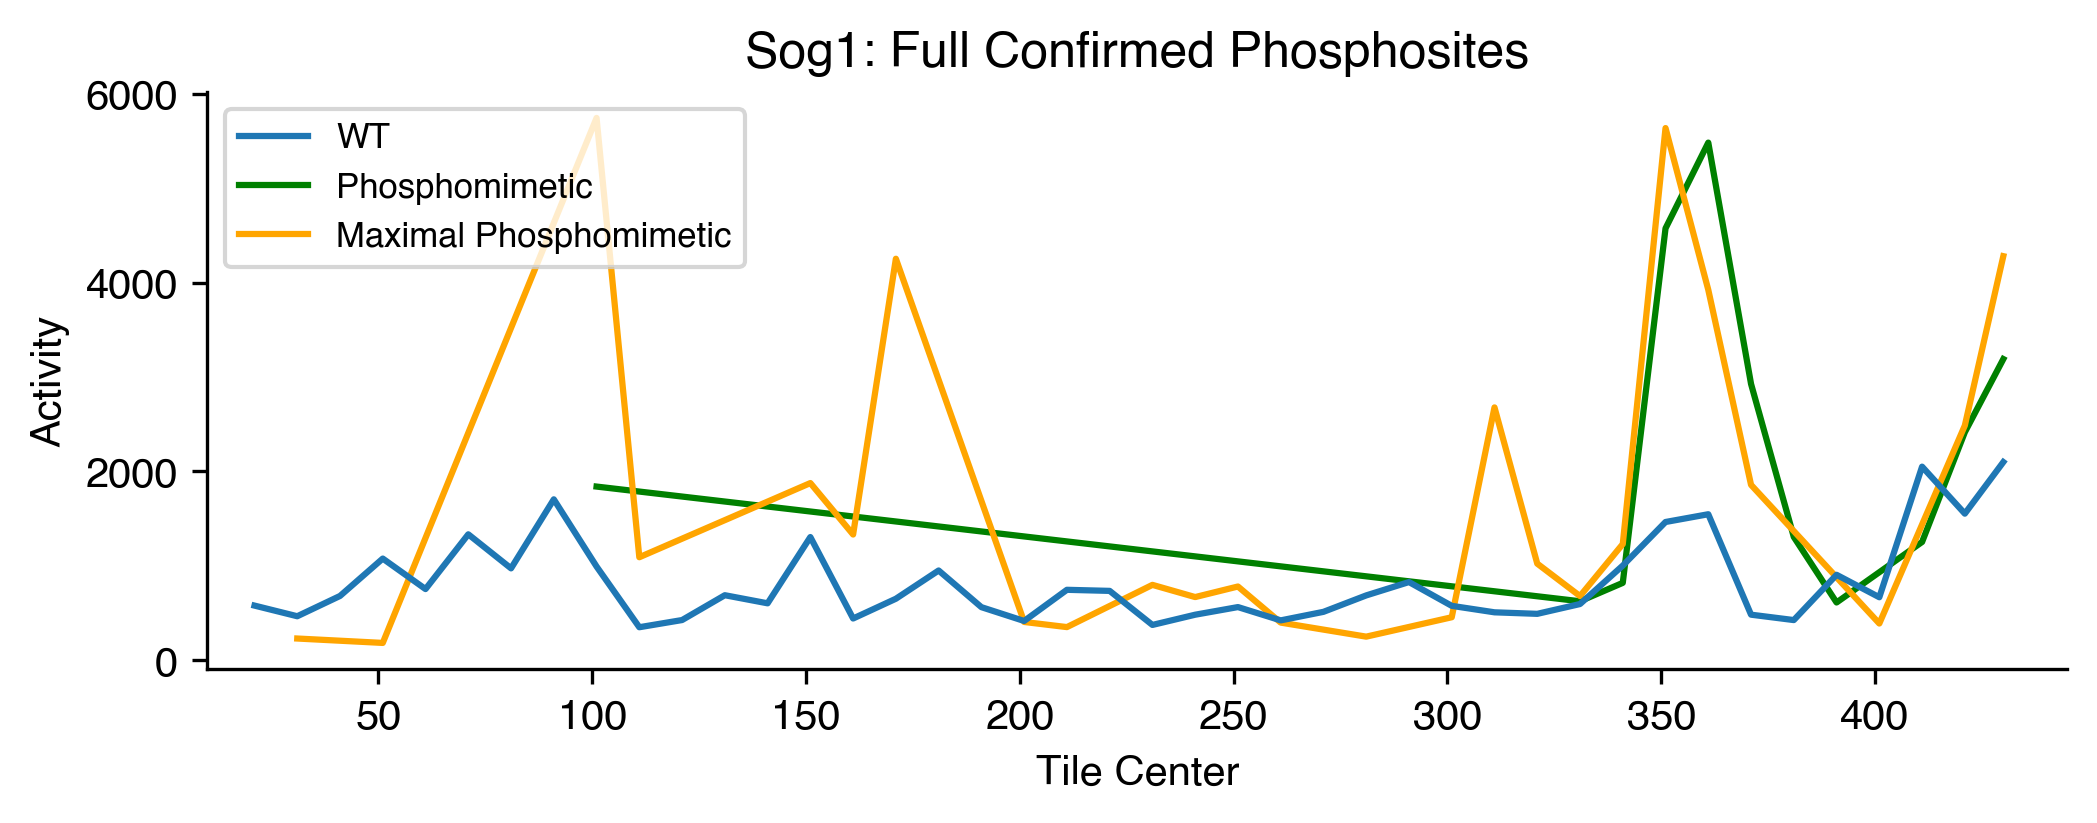

In [32]:
plt.figure(figsize = (8, 2.5), dpi = 300)
#plt.grid(zorder = 0)


ax = sns.lineplot(data = BasicArTh, x = "mid", y = activity_col, zorder = 5, label = "WT")

sns.lineplot(data = PSv_conf2fD, x = "mid", y = activity_col, label = "Phosphomimetic", color = "green", alpha = 1)
#sns.scatterplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, label = "Phosphomutant", color = "red", alpha = 0.5)

#sns.scatterplot(data = PSv_max2A_STYA, x = "mid", y = activity_col, label = "Max Phosphomutant", color = "darkred", alpha = 0.5)
sns.lineplot(data = PSv_max2D, x = "mid", y = activity_col, label = "Maximal Phosphomimetic", color = "orange", alpha = 1)


plt.xlim(10, 445)

plt.title("Sog1: Full Confirmed Phosphosites")
plt.ylabel("Activity")
plt.xlabel("Tile Center")
plt.legend(loc = "upper left", fontsize = "small")
sns.despine()

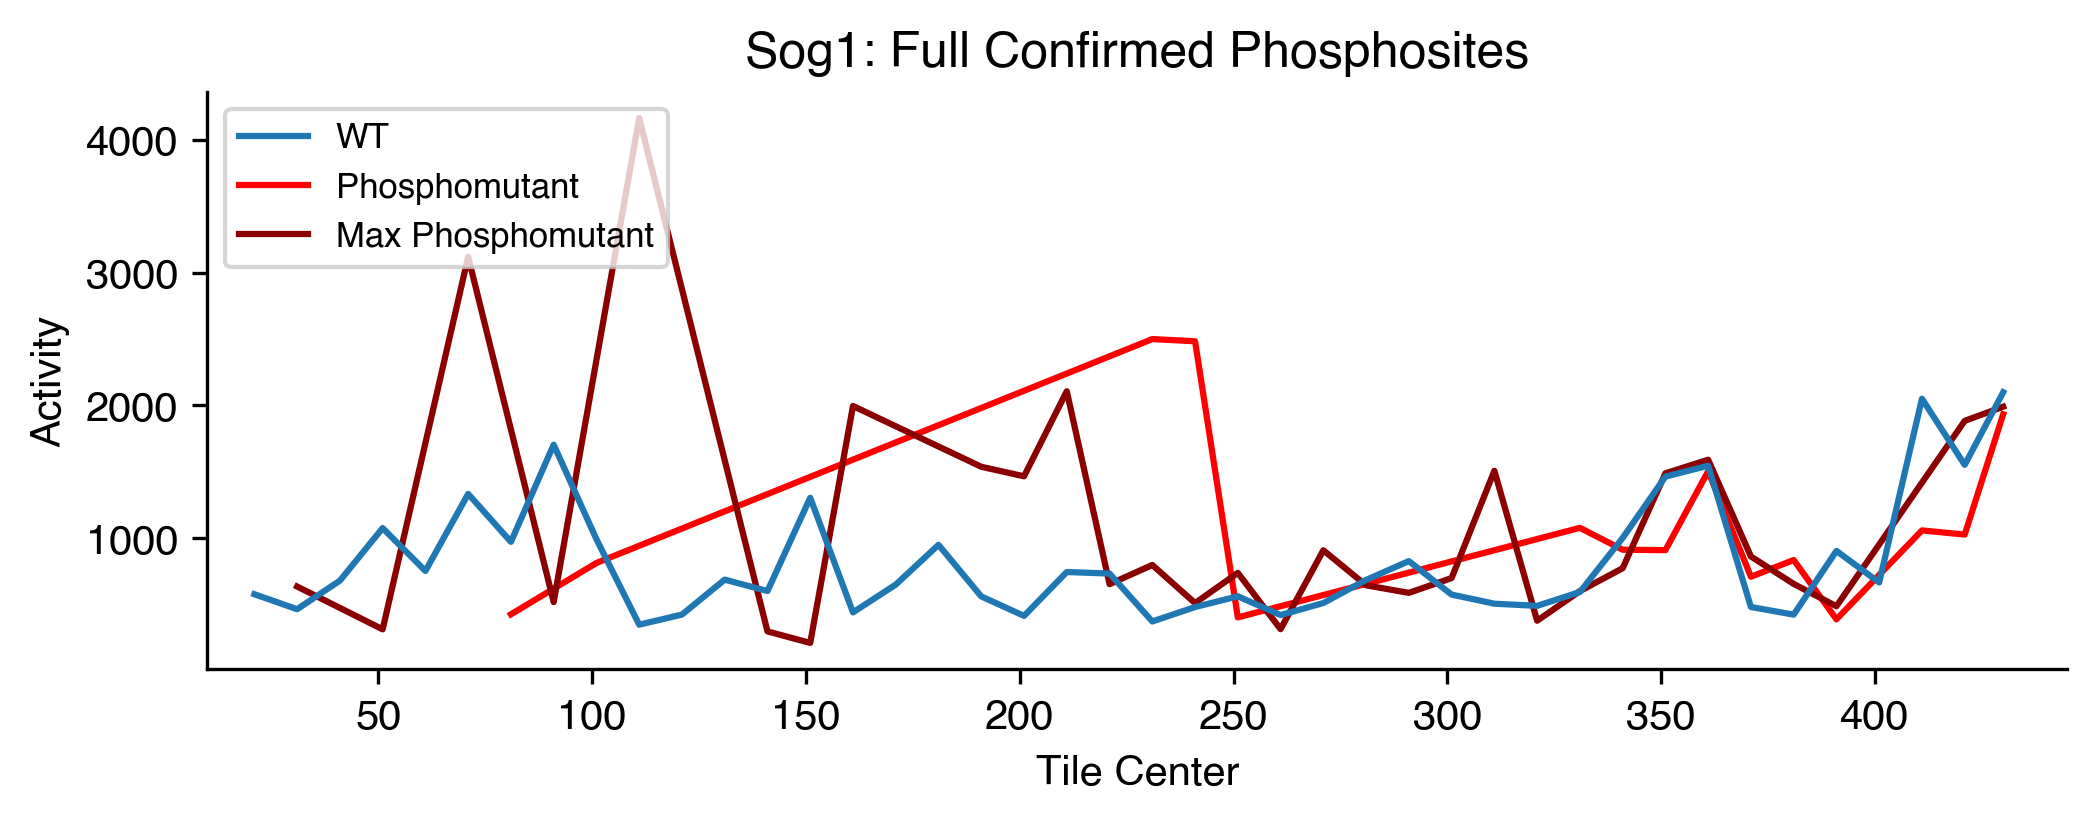

In [33]:
plt.figure(figsize = (8, 2.5), dpi = 300)
#plt.grid(zorder = 0)


ax = sns.lineplot(data = BasicArTh, x = "mid", y = activity_col, zorder = 5, label = "WT")

#sns.lineplot(data = PSv_conf2fD, x = "mid", y = activity_col, label = "Phosphomimetic", color = "green", alpha = 0.5)
sns.lineplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, label = "Phosphomutant", color = "red", alpha = 1)

sns.lineplot(data = PSv_max2A_STYA, x = "mid", y = activity_col, label = "Max Phosphomutant", color = "darkred", alpha = 1)
#sns.lineplot(data = PSv_max2D, x = "mid", y = activity_col, label = "Maximal Phosphomimetic", color = "orange", alpha = 0.5)


plt.xlim(10, 445)

plt.title("Sog1: Full Confirmed Phosphosites")
plt.ylabel("Activity")
plt.xlabel("Tile Center")
plt.legend(loc = "upper left", fontsize = "small")
sns.despine()

In [34]:
sns.color_palette('Greens')

[(0.8828143021914648, 0.9546943483275664, 0.8621914648212226),
 (0.7371472510572856, 0.895517108804306, 0.7108342945021145),
 (0.5573241061130334, 0.8164244521337947, 0.546958861976163),
 (0.3388235294117647, 0.7117262591311034, 0.40584390618992694),
 (0.17139561707035755, 0.581514801999231, 0.2979008073817762),
 (0.017762399077277974, 0.44267589388696654, 0.18523644752018453)]

In [35]:
palette = sns.color_palette('colorblind')

Text(0.5, 0, 'Tile Center')

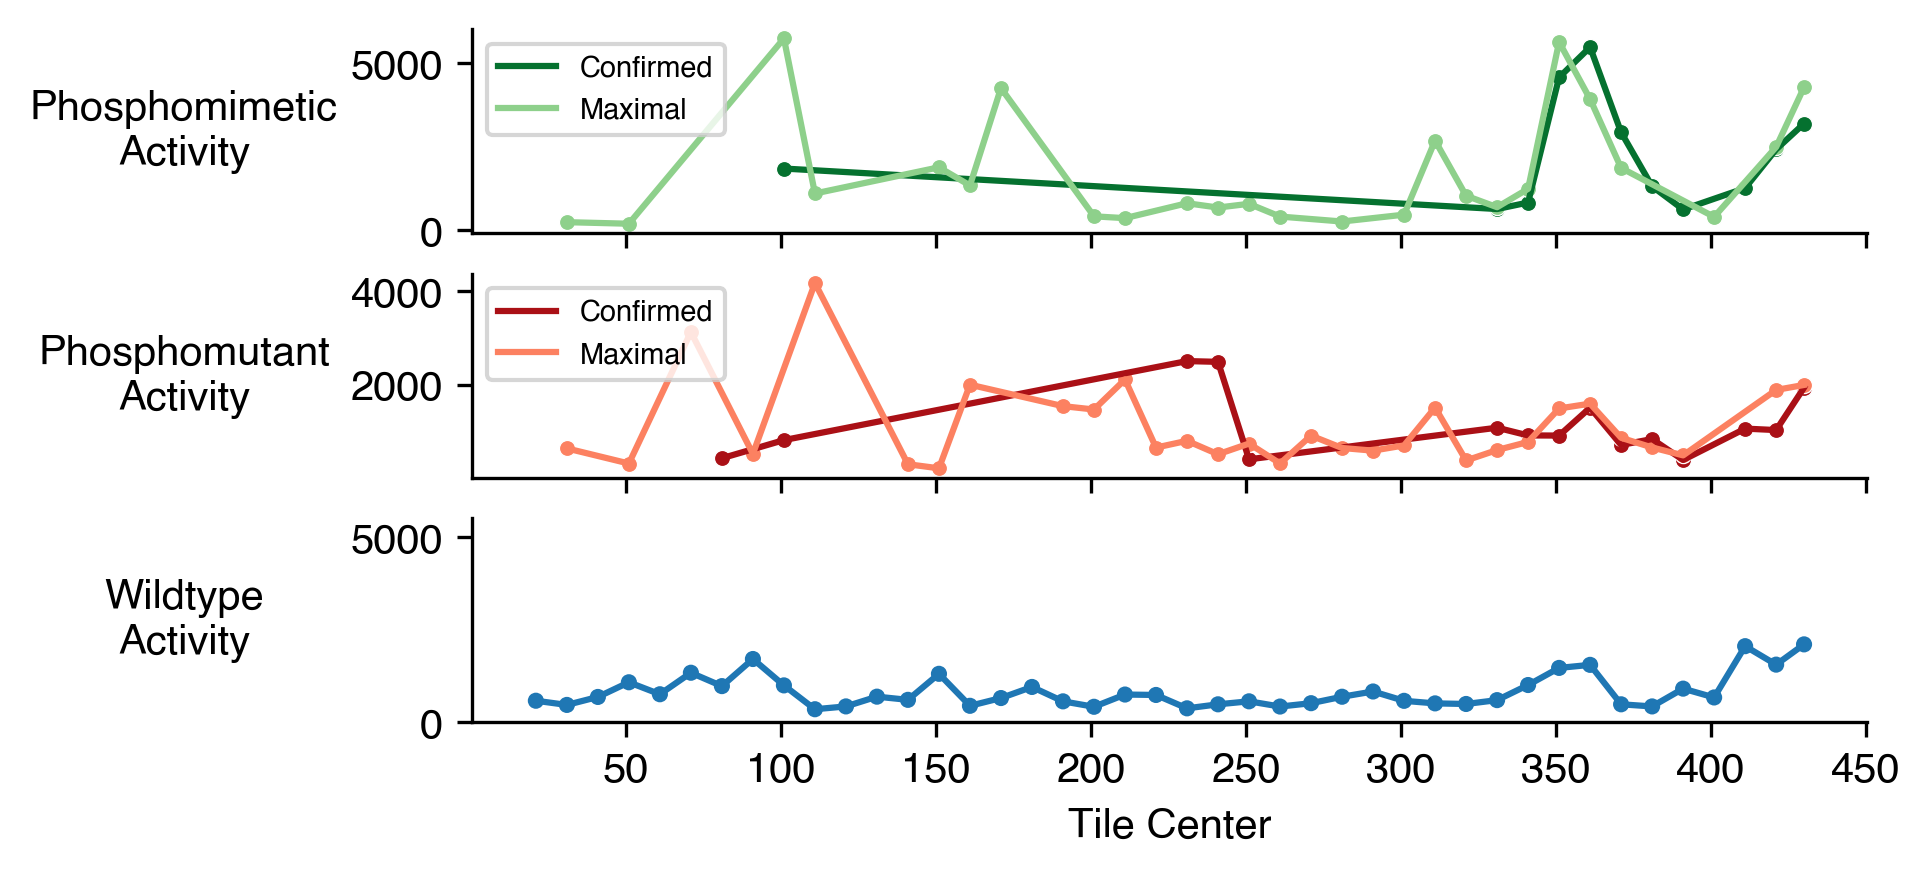

In [36]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex = True, dpi = 300, figsize = (6, 3))

sns.lineplot(data = PSv_conf2fD, x = "mid", y = activity_col, label = "Confirmed", color = sns.color_palette('Greens')[-1], alpha = 1, ax = ax1)
sns.scatterplot(data = PSv_conf2fD, x = "mid", y = activity_col, color = sns.color_palette('Greens')[-1], alpha = 1, ax = ax1, s = 15)


sns.lineplot(data = PSv_max2D, x = "mid", y = activity_col,label = "Maximal",  color = sns.color_palette('Greens')[-4], alpha = 1, ax = ax1)
sns.scatterplot(data = PSv_max2D, x = "mid", y = activity_col, color = sns.color_palette('Greens')[-4], alpha = 1, ax = ax1, s = 15)


ax1.set_ylabel("Phosphomimetic\nActivity", rotation = 0, labelpad = 40, va = "center")
ax1.legend(loc = "upper left", fontsize = 'x-small')
sns.despine(ax = ax1)

sns.lineplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, label = "Confirmed",color = sns.color_palette('Reds')[-1], alpha = 1, ax = ax2)
sns.scatterplot(data = PSv_conf2fA_STYA, x = "mid", y = activity_col, color = sns.color_palette('Reds')[-1], alpha = 1, ax = ax2, s = 15)

sns.lineplot(data = PSv_max2A_STYA, x = "mid", y = activity_col, label = "Maximal", color = sns.color_palette('Reds')[-4], alpha = 1, ax = ax2)
sns.scatterplot(data = PSv_max2A_STYA, x = "mid", y = activity_col, color = sns.color_palette('Reds')[-4], alpha = 1, ax = ax2, s = 15)

ax2.set_ylabel("Phosphomutant\nActivity", rotation = 0, labelpad = 40, va = "center")
ax2.legend(loc = "upper left", fontsize = 'x-small')
sns.despine(ax = ax2)

sns.lineplot(data = BasicArTh, x = "mid", y = activity_col, zorder = 5, ax = ax3)
sns.scatterplot(data = BasicArTh, x = "mid", y = activity_col, zorder = 5, ax = ax3, s= 15, edgecolor = 'none')

ax3.set_ylim(0, 5500)
ax3.set_ylabel("Wildtype\nActivity", rotation = 0, labelpad = 40, va = "center")
#ax3.legend(bbox_to_anchor = (1, 1))
sns.despine(ax = ax3)
ax3.set_xlabel("Tile Center")



In [740]:
palette_2 = sns.color_palette('rocket')
palette_2

[(0.20973515, 0.09747934, 0.24238489),
 (0.43860848, 0.12177004, 0.34119475),
 (0.67824099, 0.09192342, 0.3504148),
 (0.8833417, 0.19830556, 0.26014181),
 (0.95381595, 0.46373781, 0.31769923),
 (0.96516917, 0.70776351, 0.5606593)]

### fig, ax = plt.subplots(figsize = (8, 2), dpi = 300)

sog1_helpers.plot_all_tiles(PSv_conf2fA_STYA_vs_basic, activity_col + "_var", ax=ax,  color =  palette_2[0], label = "Phosphomutant", alpha = 0.6)
sog1_helpers.plot_all_tiles(BasicArTh, activity_col, ax=ax,  color = palette_2[2], label = "WT", alpha = 0.6)
sog1_helpers.plot_all_tiles(PSv_conf2fD_vs_basic, activity_col + "_var", ax=ax,  color =  palette_2[4], label = "Phosphomimetic", alpha = 0.6)

plt.legend(fontsize = 'x-small')
plt.xlabel("Position")
plt.ylabel("Activity")
plt.title("Full Confirmed Variants")

#plt.xlim(300, 451)
sns.despine()